In [1]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from collections import Counter

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
def k_dist(data,ks,ke,kgap):
    fig, ax = plt.subplots(figsize=(3,3))
    for minPts in range(ks, ke, kgap):
        nbrs = NearestNeighbors(n_neighbors=minPts)
        nbrs.fit(data)

        distances, indices = nbrs.kneighbors(data)
        k_distances = np.sort(distances[:,minPts-1])
        ax.plot(k_distances,label='minPts={}'.format(minPts))

    ax.legend(fontsize=12)
    ax.set_xlabel('Points sorted',fontsize=16)
    ax.set_ylabel('Cluster distance', fontsize=16)
    ax.xaxis.set_tick_params(labelsize=14)
    ax.yaxis.set_tick_params(labelsize=14)
    return ax
    

In [3]:
def plot_cluster(data, labels):
    fig, ax = plt.subplots(figsize=(3,3))
    scatter = ax.scatter(data[:,0], data[:,1], c=labels, s=1)

    counts = Counter(labels)
    handles = []
    for lab, cnt in counts.items():
        if lab == -1:
            name = "Noise ({:.2f})".format(cnt/len(data))
            color = 'k'
        else:
            name = "Clt.{} ({:.2f})".format(lab,cnt/len(data))
            color = scatter.cmap(scatter.norm(lab))
    
        handles.append(
            plt.Line2D(
                [0], [0],
                marker='o',
                color='w',
                label=name,
                markerfacecolor=color,
                markersize=8
            )
        )
    ax.set_xlim(-7,7)
    ax.set_ylim(-7,7)

    ax.xaxis.set_ticks(np.arange(-6,6.01,4))
    ax.yaxis.set_ticks(np.arange(-6,6.01,4))

    ax.xaxis.set_tick_params(labelsize=14)
    ax.yaxis.set_tick_params(labelsize=14)

    ax.set_xlabel('PC1',fontsize=14)
    ax.set_ylabel('PC2',fontsize=14)
    ax.legend(handles=handles, fontsize=8, ncol=2,columnspacing=0.5)

    plt.tight_layout()
    return ax

In [4]:
def savelabels(labels, name, desc='dbscan_labels'):
    label_name = list(Counter(labels).keys())
    output = {}
    for lb in label_name:
        output[lb] = np.where(labels==lb)[0]

    np.save('{}/{}.npy'.format(desc,name), output)

## A2T

In [5]:
X_a2t = np.load("../../PCA/PCA_model_dihed/pca_coord_a2t.npy")
X_pca_a2t = X_a2t[:,:2]

#ax = k_dist(X_pca_a2t, 10, 600, 100)
#plt.tight_layout()
#plt.savefig('dbscan_test/A2T_test.png',dpi=800, bbox_inches='tight')
###ax.set_xlim(0,200000)
###ax.set_ylim(0,1.5)

In [6]:
db_a2t = DBSCAN(eps=0.25, min_samples=400)
labels_a2t = db_a2t.fit_predict(X_pca_a2t)

#np.mean(labels==-1)

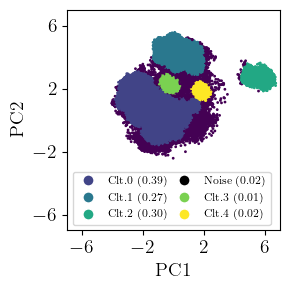

In [32]:
ax_a2t = plot_cluster(X_pca_a2t, labels_a2t)
plt.savefig('dbscan_cluster/A2T_cluster.png',dpi=800, bbox_inches='tight')

In [8]:
savelabels(labels_a2t, 'a2t')

## A2V

In [9]:
X_a2v = np.load("../../PCA/PCA_model_dihed/pca_coord_a2v.npy")
X_pca_a2v = X_a2v[:,:2]
#
#ax = k_dist(X_pca_a2v, 10, 600, 100)
#ax.xaxis.set_ticks(np.arange(0,160000.1,80000))
#ax.yaxis.set_ticks(np.arange(0,2.01,0.5))
#plt.tight_layout()
#plt.savefig('dbscan_test/A2V_test.png',dpi=800, bbox_inches='tight')

In [10]:
db_a2v = DBSCAN(eps=0.2, min_samples=400)
labels_a2v = db_a2v.fit_predict(X_pca_a2v)

#np.mean(labels==-1)

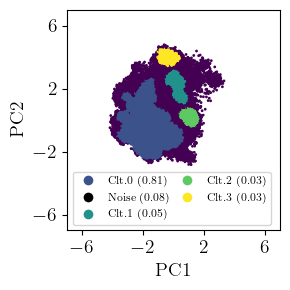

In [11]:
ax_a2v = plot_cluster(X_pca_a2v, labels_a2v)
#plt.savefig('dbscan_cluster/A2V_cluster.png',dpi=800, bbox_inches='tight')

In [12]:
savelabels(labels_a2v, 'a2v')

## WT

In [13]:
X_wt = np.load("../../PCA/PCA_model_dihed/pca_coord_wt.npy")
X_pca_wt = X_wt[:,:2]
#
#ax = k_dist(X_pca_wt, 10, 600, 100)
#ax.xaxis.set_ticks(np.arange(0,160000.1,80000))
#ax.yaxis.set_ticks(np.arange(0,2.51,0.5))
#plt.tight_layout()
#plt.savefig('dbscan_test/WT_test.png',dpi=800, bbox_inches='tight')

In [14]:
db_wt = DBSCAN(eps=0.2, min_samples=600)
labels_wt = db_wt.fit_predict(X_pca_wt)

#np.mean(labels==-1)

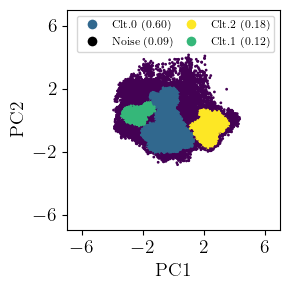

In [15]:
ax_wt = plot_cluster(X_pca_wt, labels_wt)
#plt.savefig('dbscan_cluster/WT_cluster.png',dpi=800, bbox_inches='tight')

In [16]:
savelabels(labels_wt, 'wt')

## WTD

In [17]:
X_wtd = np.load("../../PCA/PCA_model_dihed/pca_coord_wtd.npy")
X_pca_wtd = X_wtd[:,:2]
#
#ax = k_dist(X_pca_wtd, 10, 700, 100)
##ax.xaxis.set_ticks(np.arange(0,160000.1,80000))
#ax.yaxis.set_ticks(np.arange(0,3.01,0.5))
#plt.tight_layout()
#plt.savefig('dbscan_test/WTD_test.png',dpi=800, bbox_inches='tight')

In [18]:
db_wtd = DBSCAN(eps=0.1, min_samples=200)
labels_wtd = db_wtd.fit_predict(X_pca_wtd)

#np.mean(labels==-1)

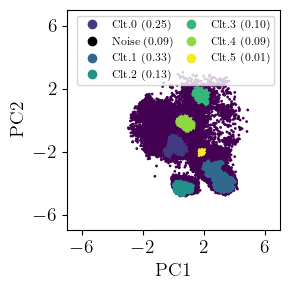

In [19]:
ax_wtd = plot_cluster(X_pca_wtd, labels_wtd)
#plt.savefig('dbscan_cluster/WTD_cluster.png',dpi=800, bbox_inches='tight')

In [20]:
savelabels(labels_wtd, 'wtd')

## A2T Cbeta

In [21]:
X_a2t_beta = np.load("../../PCA/PCA_model_dihed/pca_coord_a2t_beta.npy")
X_pca_a2t_beta = X_a2t_beta[:,:2]
#
#ax = k_dist(X_pca_a2t_beta, 10, 700, 100)
##ax.xaxis.set_ticks(np.arange(0,160000.1,80000))
#ax.yaxis.set_ticks(np.arange(0,2.01,0.5))
#plt.tight_layout()
#plt.savefig('dbscan_test/A2T_beta_test.png',dpi=800, bbox_inches='tight')

In [22]:
db_a2t_beta = DBSCAN(eps=0.172, min_samples=600)
labels_a2t_beta = db_a2t_beta.fit_predict(X_pca_a2t_beta)

#np.mean(labels==-1)

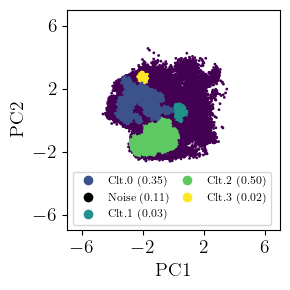

In [33]:
ax_a2t_beta = plot_cluster(X_pca_a2t_beta, labels_a2t_beta)
plt.savefig('dbscan_cluster/A2T_beta_cluster.png',dpi=800, bbox_inches='tight')

In [24]:
savelabels(labels_a2t_beta, 'a2t_beta')

In [25]:
np.max(list(Counter(labels_a2t_beta).keys()))

3

In [26]:
label2 = np.where(labels_a2t_beta==2)
len(label2[0].tolist())

100582

## A2V 1-6D

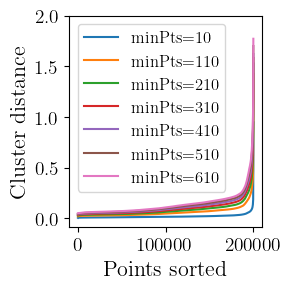

In [27]:
X_a2vd = np.load("../../PCA/PCA_model_dihed/pca_coord_a2vd.npy")
X_pca_a2vd = X_a2vd[:,:2]

ax = k_dist(X_pca_a2t_beta, 10, 700, 100)
#ax.xaxis.set_ticks(np.arange(0,160000.1,80000))
ax.yaxis.set_ticks(np.arange(0,2.01,0.5))
plt.tight_layout()
plt.savefig('dbscan_test/A2VD_test.png',dpi=800, bbox_inches='tight')

In [28]:
db_a2vd = DBSCAN(eps=0.25, min_samples=600)
labels_a2vd = db_a2vd.fit_predict(X_pca_a2vd)

np.mean(labels_a2vd==-1)

0.02904

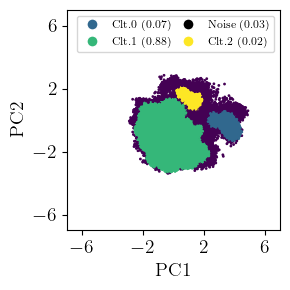

In [31]:
ax_a2vd = plot_cluster(X_pca_a2vd, labels_a2vd)
plt.savefig('dbscan_cluster/A2VD_cluster.png',dpi=800, bbox_inches='tight')

In [30]:
savelabels(labels_a2vd, 'a2vd')